In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [145]:
df = pd.read_csv('../../data/heart_disease.csv')

In [146]:
df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect,num
0,0.936181,0.691095,0.750380,-0.276443,2.430427,0.017494,-0.696419,1.068965,3.451528,-0.444500,...,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,3.937004,-0.794901,0
1,1.378929,0.691095,1.596266,0.744555,-0.411450,-1.816334,1.435916,0.381773,-0.289727,-0.444500,...,1.080686,-0.275839,-1.189384,-0.529313,-0.383038,3.721559,0.900542,-0.254000,-0.794901,1
2,1.378929,0.691095,-0.659431,-0.353500,-0.411450,-0.899420,1.435916,1.326662,-0.289727,-0.444500,...,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018,1
3,-1.941680,0.691095,-0.095506,0.051047,-0.411450,1.633010,-0.696419,2.099753,-0.289727,-0.444500,...,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901,0
4,-1.498933,-1.446980,-0.095506,-0.835103,-0.411450,0.978071,-0.696419,0.295874,-0.289727,2.249717,...,-0.925338,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.272059,-1.446980,0.468418,-0.122330,-0.411450,-1.161395,1.435916,-0.734914,-0.289727,-0.444500,...,1.080686,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,-0.254000,1.258018,1
293,-1.056185,0.691095,-1.223355,0.320744,-0.411450,-0.768432,-0.696419,0.124076,3.451528,-0.444500,...,1.080686,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,-0.254000,1.258018,1
294,1.489615,0.691095,0.693988,-1.047008,2.430427,-0.375469,-0.696419,2.013854,-0.289727,-0.444500,...,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018,1
295,0.272059,0.691095,-0.095506,-2.241384,-0.411450,-1.510696,1.435916,0.124076,-0.289727,-0.444500,...,1.080686,-0.275839,-1.189384,1.889241,-0.383038,-0.268705,-1.110443,-0.254000,1.258018,1


In [147]:
# x = df.drop(columns = ['Unnamed: 0','num'])
x = df.drop(columns = ['num'])
y = df['num']

In [148]:
x

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
0,0.936181,0.691095,0.750380,-0.276443,2.430427,0.017494,-0.696419,1.068965,3.451528,-0.444500,...,-0.937948,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,3.937004,-0.794901
1,1.378929,0.691095,1.596266,0.744555,-0.411450,-1.816334,1.435916,0.381773,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,-0.383038,3.721559,0.900542,-0.254000,-0.794901
2,1.378929,0.691095,-0.659431,-0.353500,-0.411450,-0.899420,1.435916,1.326662,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018
3,-1.941680,0.691095,-0.095506,0.051047,-0.411450,1.633010,-0.696419,2.099753,-0.289727,-0.444500,...,-0.937948,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901
4,-1.498933,-1.446980,-0.095506,-0.835103,-0.411450,0.978071,-0.696419,0.295874,-0.289727,2.249717,...,1.066157,-0.925338,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.272059,-1.446980,0.468418,-0.122330,-0.411450,-1.161395,1.435916,-0.734914,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,-0.254000,1.258018
293,-1.056185,0.691095,-1.223355,0.320744,-0.411450,-0.768432,-0.696419,0.124076,3.451528,-0.444500,...,-0.937948,1.080686,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,-0.254000,1.258018
294,1.489615,0.691095,0.693988,-1.047008,2.430427,-0.375469,-0.696419,2.013854,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018
295,0.272059,0.691095,-0.095506,-2.241384,-0.411450,-1.510696,1.435916,0.124076,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,1.889241,-0.383038,-0.268705,-1.110443,-0.254000,1.258018


In [149]:
y

0      0
1      1
2      1
3      0
4      0
      ..
292    1
293    1
294    1
295    1
296    1
Name: num, Length: 297, dtype: int64

In [150]:
pca = PCA(0.95)
x_pca = pca.fit_transform(x)
x_pca

array([[-1.22209659e+00, -2.14712859e+00,  3.52746780e+00, ...,
        -9.94617748e-01, -1.47079183e+00, -6.12919948e-01],
       [-3.09709119e+00, -2.05052147e+00, -1.52793913e-01, ...,
         5.68456370e-01,  1.76720065e+00,  4.52348965e-01],
       [-3.88845096e+00, -4.66689640e-02, -7.30722628e-01, ...,
        -1.04375248e+00,  8.13359983e-01, -2.73336163e-01],
       ...,
       [-3.05066632e+00,  1.27598499e+00, -2.43066699e-03, ...,
        -9.00725872e-02, -6.54498425e-01,  1.40507919e+00],
       [-2.73530554e+00,  2.89598349e+00, -8.87449849e-01, ...,
         5.44031700e-01, -1.01691969e-01, -2.65043402e-01],
       [ 8.46020777e-01, -1.82659121e+00, -1.24570360e+00, ...,
         1.24130175e+00, -7.73088675e-01, -3.20723123e-01]],
      shape=(297, 18))

In [151]:
pca.n_components_

np.int64(18)

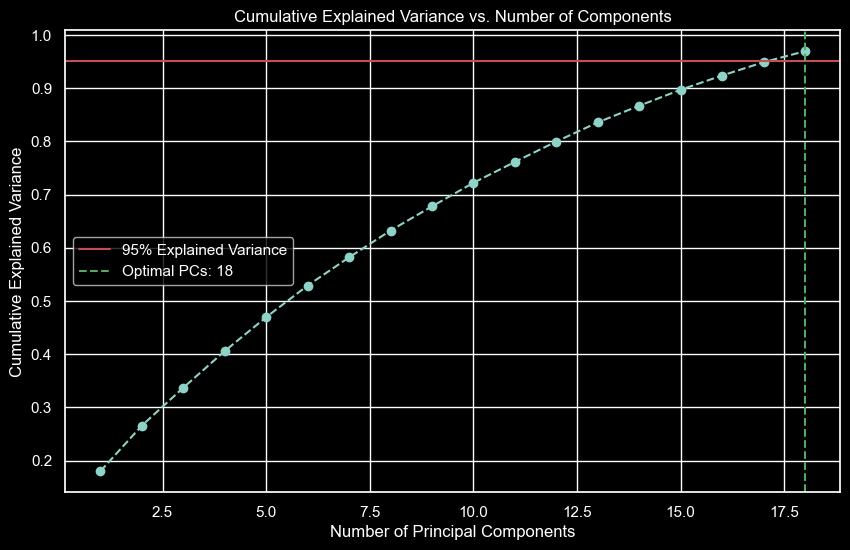

In [152]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance')
plt.axvline(x=pca.n_components_, color='g', linestyle='--', label=f'Optimal PCs: {pca.n_components_}')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs. Number of Components')
plt.legend()
plt.grid(True)

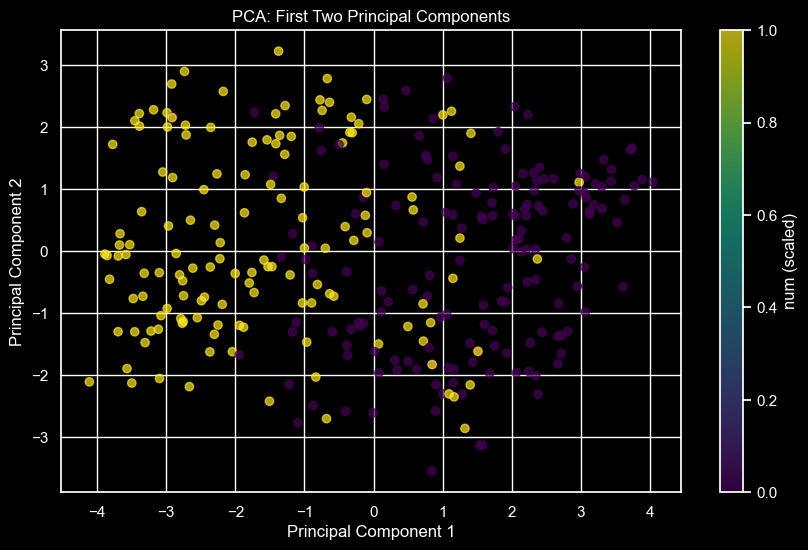

In [153]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: First Two Principal Components')
plt.colorbar(scatter, label='num (scaled)')
plt.grid(True)

In [154]:
column_names = [f'PC{i+1}' for i in range(x_pca.shape[1])]
df_pca = pd.DataFrame(x_pca, columns=column_names)
df_pca['target'] = y
df_pca.to_csv('../data/heart_disease_pca.csv', index=False)